===== FINAL RESULTS =====
Logistic Regression: 0.7882018479033405
Random Forest     : 0.7882018479033405
XGBoost           : 0.7789623312011372

Confusion Matrix:
 [[913 120]
 [191 183]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.85      1033
           1       0.60      0.49      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



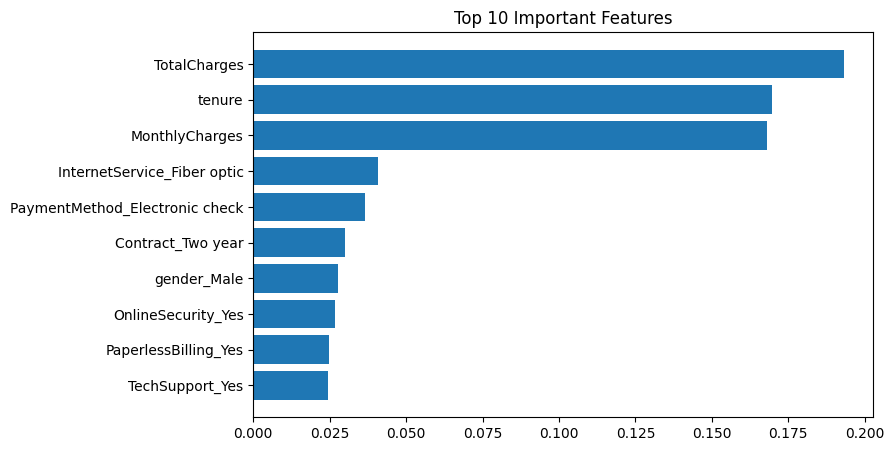

In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# Load dataset
df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Preprocessing
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

df.drop('customerID', axis=1, inplace=True)

df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

df = pd.get_dummies(df, drop_first=True)

# Split
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models
lr = LogisticRegression(max_iter=3000)
rf = RandomForestClassifier(n_estimators=500, random_state=42)
xgb = XGBClassifier(n_estimators=500, learning_rate=0.05, random_state=42, eval_metric='logloss')

# Train
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

# Results
print("===== FINAL RESULTS =====")
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest     :", accuracy_score(y_test, y_pred_rf))
print("XGBoost           :", accuracy_score(y_test, y_pred_xgb))

# Report
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

import matplotlib.pyplot as plt

# Feature Importance from Random Forest
importances = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
plt.barh(feat_df['Feature'][:10], feat_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()